In [1]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

Running FARGOpy version 0.4.0


In [2]:
fp.Simulation.download_precomputed(setup='p3disoj')
sim = fp.Simulation(output_dir='/tmp/p3disoj')

Precomputed output directory '/tmp/p3disoj' already exist
Your simulation is now connected with '/home/jupitergeci/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat:
  Name: Jupiter, Distance: 1.0, Mass: 0.001
Configuration variables and domains load into the object. See e.g. <sim>.vars


# 1D Interpolation


In [3]:
data1d = sim.load_field(
    fields=['gasdens'],
    slice='phi=0,theta=1.56',
    snapshot=10,
    interpolate=True
)

In [ ]:
xsim = data1d.var1_mesh[0]
ysim = data1d.var2_mesh[0]
zsim = data1d.var3_mesh[0]

rsim = np.sqrt(xsim**2 + ysim**2 + zsim**2)

rho1d = data1d.gasdens_mesh[0]

In [9]:
rho1d_interp = data1d.evaluate(
    time=10,
    var1=rsim,
    interpolator='griddata',
    method='linear')

Running FARGOpy version 0.4.0
[0.5078125 0.5234375 0.5390625 0.5546875 0.5703125 0.5859375 0.6015625
 0.6171875 0.6328125 0.6484375 0.6640625 0.6796875 0.6953125 0.7109375
 0.7265625 0.7421875 0.7578125 0.7734375 0.7890625 0.8046875 0.8203125
 0.8359375 0.8515625 0.8671875 0.8828125 0.8984375 0.9140625 0.9296875
 0.9453125 0.9609375 0.9765625 0.9921875 1.0078125 1.0234375 1.0390625
 1.0546875 1.0703125 1.0859375 1.1015625 1.1171875 1.1328125 1.1484375
 1.1640625 1.1796875 1.1953125 1.2109375 1.2265625 1.2421875 1.2578125
 1.2734375 1.2890625 1.3046875 1.3203125 1.3359375 1.3515625 1.3671875
 1.3828125 1.3984375 1.4140625 1.4296875 1.4453125 1.4609375 1.4765625
 1.4921875]


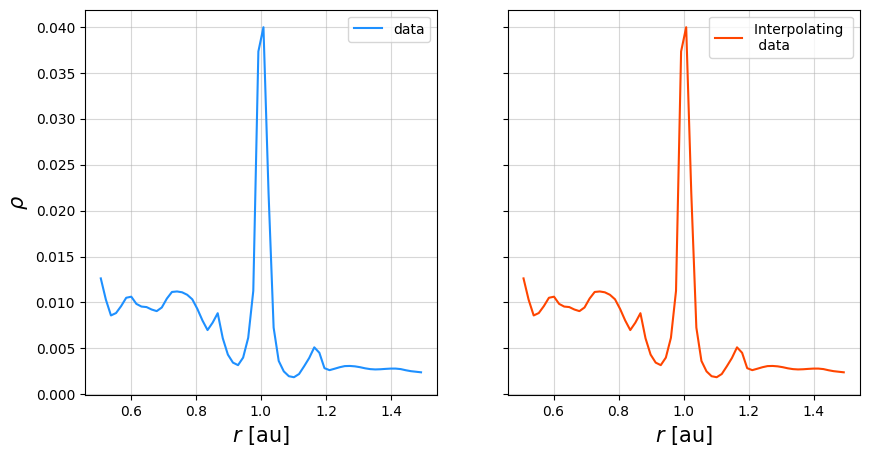

In [7]:
fig,axs = plt.subplots(1,2,figsize=(10,5),sharex=True,sharey=True) 
axs[0].plot(rsim,rho1d,color='dodgerblue',label='data')
axs[1].plot(rsim,rho1d_interp,color='orangered',label='Interpolating \n data')

for i in range(2):
    axs[i].grid(alpha=0.5) 
    axs[i].legend()
    axs[i].set_xlabel(f'$r$ [au]',size=15)
    axs[0].set_ylabel(r'$\rho$',size=15)

plt.show()

# Cross-validation and error metrics for 1D interpolation

Below, a Leave-One-Out (LOO) cross-validation is implemented to quantify the quality of the interpolation over the 1D cut (r, density). Metrics such as MAE, MSE, RMSE, and the mean relative error are calculated, and the distribution of the residuals is visualized.

MAE (1D): 9.088e-04
MSE (1D): 6.450e-06
RMSE (1D): 2.540e-03
Mean relative error (1D): 9.068%


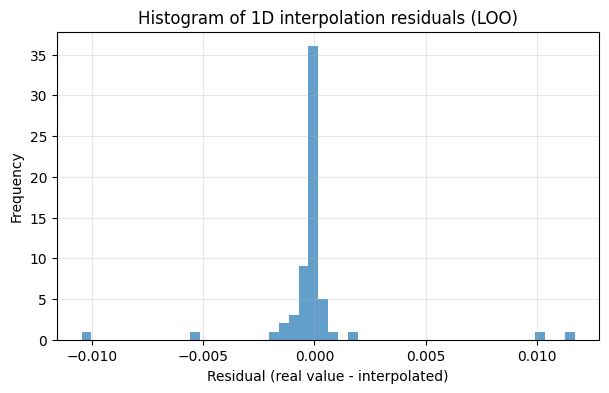

In [7]:
from sklearn.model_selection import LeaveOneOut
from scipy.interpolate import griddata

# 1D data: r vs density
r_points = rsim.flatten()
values_1d = rho1d.flatten()

loo_1d = LeaveOneOut()
errors_1d = []
rel_errors_1d = []
true_vals_1d = []
pred_vals_1d = []

for train_idx, test_idx in loo_1d.split(r_points.reshape(-1, 1)):
    train_r, test_r = r_points[train_idx], r_points[test_idx]
    train_val, test_val = values_1d[train_idx], values_1d[test_idx]
    interp_val = griddata(train_r, train_val, test_r, method='linear')
    if np.isnan(interp_val):
        continue
    error = test_val[0] - interp_val[0]
    rel_error = np.abs(error) / np.abs(test_val[0]) if test_val[0] != 0 else np.nan
    errors_1d.append(error)
    rel_errors_1d.append(rel_error)
    true_vals_1d.append(test_val[0])
    pred_vals_1d.append(interp_val[0])

errors_1d = np.array(errors_1d)
rel_errors_1d = np.array(rel_errors_1d)

mae_1d = np.mean(np.abs(errors_1d))
mse_1d = np.mean(errors_1d**2)
rmse_1d = np.sqrt(mse_1d)
mean_rel_error_1d = np.nanmean(rel_errors_1d)

print(f"MAE (1D): {mae_1d:.3e}")
print(f"MSE (1D): {mse_1d:.3e}")
print(f"RMSE (1D): {rmse_1d:.3e}")
print(f"Mean relative error (1D): {mean_rel_error_1d:.3%}")

plt.figure(figsize=(7,4))
plt.hist(errors_1d, bins=50, alpha=0.7)
plt.xlabel('Residual (real value - interpolated)')
plt.ylabel('Frequency')
plt.title('Histogram of 1D interpolation residuals (LOO)')
plt.grid(alpha=0.3)
plt.show()

MAE (1D): 9.088e-04  
MSE (1D): 6.450e-06  
RMSE (1D): 2.540e-03  
Mean relative error (1D): 9.068%

These results show that the 1D interpolation presents a low absolute and quadratic error in absolute terms, although the mean relative error is higher than in the 2D case. This may be due to the greater sensitivity of 1D interpolation to abrupt gradients or the smaller number of points available in the cut. However, the error remains reasonably low for scientific applications, especially considering the presence of shocks and sharp variations in density.

# 2D Interpolation

In [8]:
data2d = sim.load_field(
    fields=['gasdens'],
    slice='phi=0',
    snapshot=10,
    interpolate=True
)

xsim= data2d.var1_mesh[0]
ysim = data2d.var2_mesh[0]
zsim = data2d.var3_mesh[0]
rho2dsim = data2d.gasdens_mesh[0]

Loading density field for slice: phi=0


In [9]:
rho2d_interp= data2d.evaluate(
    time=10,
    var1=xsim,
    var3=zsim,
    interpolator='griddata',
    method='linear')

Running FARGOpy version 0.4.0


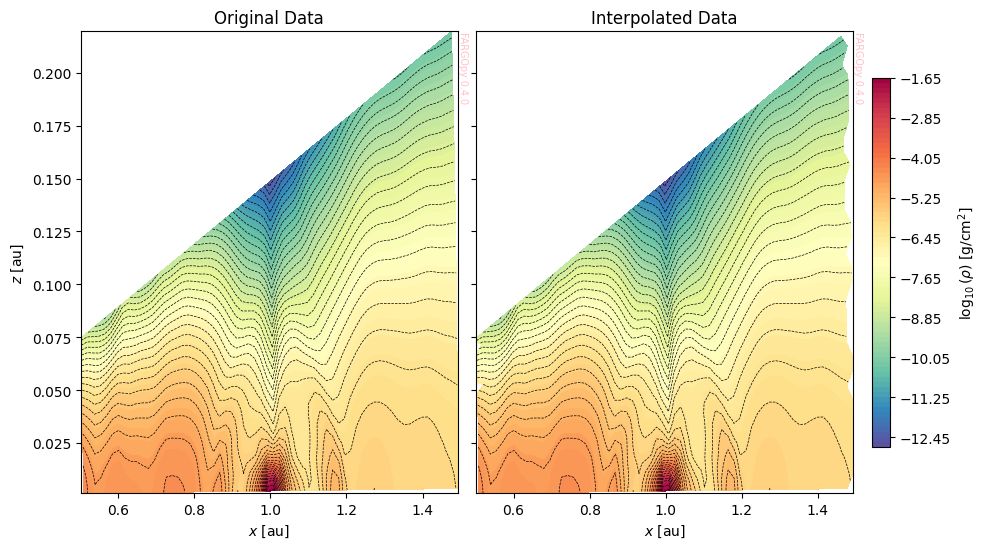

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.05})

cmap = 'Spectral_r'

# Interpolated data
pc1 = axs[0].contourf(xsim, zsim, np.log(rho2dsim), cmap=cmap, levels=100)
axs[0].contour(xsim, zsim, np.log(rho2dsim), levels=50, colors='k', linewidths=0.5)
axs[0].set_xlabel('$x$ [au]')
axs[0].set_ylabel('$z$ [au]')
axs[0].set_title('Original Data')
fp.Plot.fargopy_mark(axs[0])

# Interpolated data
pc2 = axs[1].contourf(xsim, zsim, np.log(rho2d_interp), cmap=cmap, levels=100)
axs[1].contour(xsim, zsim, np.log(rho2d_interp), levels=50, colors='k', linewidths=0.5)
axs[1].set_xlabel('$x$ [au]')
axs[1].set_title('Interpolated Data')
fp.Plot.fargopy_mark(axs[1])

# Shared colorbar
cbar = fig.colorbar(pc2, ax=axs, location='right', shrink=0.8, pad=0.02)
cbar.set_label(r'$\log_{10}(\rho)$ [g/cm$^2$]')

plt.tight_layout()
plt.show()

# Cross-validation and error metrics for 2D interpolation

Below, a Leave-One-Out (LOO) cross-validation is implemented to quantify the quality of the interpolation over the 2D cut (x, z, density). Metrics such as MAE, MSE, RMSE, and the mean relative error are calculated, and the distribution of the residuals is visualized.

## Quantitative evaluation of interpolation quality

To quantify the quality of the interpolation applied to the protoplanetary disk data, a Leave-One-Out (LOO) cross-validation was implemented on the 2D cut (x, z, density). This method consists of:

- Removing one point from the original sample.
- Interpolating the value of that point using the rest of the data.
- Comparing the interpolated value with the real value.
- Repeating the process for all points in the dataset.

This approach is especially robust for small or irregular datasets, such as those resulting from numerical simulations on non-uniform meshes. It allows for a realistic estimation of interpolation error, since each point is evaluated as if it were unknown.

The following statistical metrics were calculated to quantify the error:

- **MAE (Mean Absolute Error):** Average of the absolute value of the errors.
- **MSE (Mean Squared Error):** Average of the squared errors.
- **RMSE (Root Mean Squared Error):** Square root of the MSE, useful for interpreting the error in the same units as the original variable.
- **Mean relative error:** Average of the absolute relative error with respect to the real value, expressed as a percentage.

In addition, the distribution of the residuals (difference between real and interpolated value) was visualized using a histogram, which allows for the identification of possible biases or the presence of outliers.

This analysis provides a quantitative and visual validation of the interpolation quality, which is essential to ensure the reliability of scientific results derived from these data, especially in regions with abrupt gradients or shocks.

## Justification of the reliability of the method

The use of Leave-One-Out (LOO) cross-validation to assess interpolation quality is widely accepted in the scientific literature and in numerical analysis applications, for the following reasons:

- **Realistic and unbiased evaluation:** LOO simulates the process of predicting values at unseen points, removing each point one by one and estimating its value from the rest. This allows for an objective and non-overfitted measurement of interpolation error, since each prediction is made on data not seen by the interpolator.

- **Full use of the data:** In contexts where the amount of data is limited (such as expensive numerical simulations), LOO allows all available information to be used, maximizing the statistical robustness of the evaluation.

- **Detection of problematic areas:** By analyzing the residuals point by point, it is possible to identify regions where interpolation is less accurate, such as areas with shocks or abrupt gradients, which provides valuable information to improve the model or mesh.

- **Standard and comparable metrics:** The obtained metrics (MAE, MSE, RMSE, relative error) are standard and allow for comparison of interpolation quality between different methods, configurations, or datasets.

- **Recommended in the literature:** Cross-validation methods such as LOO are recommended in reference books and articles on interpolation and data analysis (see, for example, Hastie, Tibshirani & Friedman, "The Elements of Statistical Learning").

For these reasons, LOO cross-validation provides a reliable and rigorous estimate of interpolation quality, especially in scientific contexts where precision and reproducibility are fundamental.

MAE: 1.133e-04
MSE: 2.870e-06
RMSE: 1.694e-03
Mean relative error: 0.630%


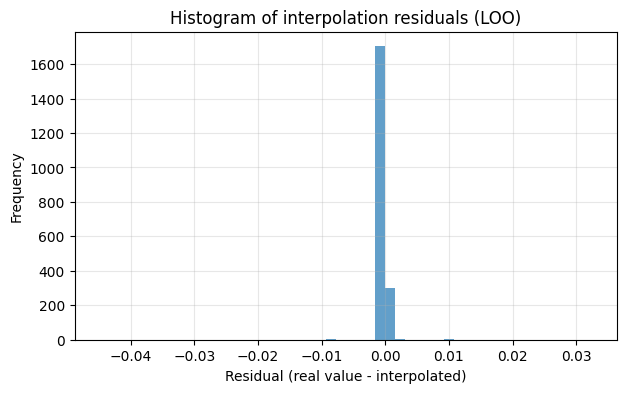

In [11]:
from sklearn.model_selection import LeaveOneOut
from scipy.interpolate import griddata

# Flatten the original data to work with individual points
data_points = np.column_stack((xsim.flatten(), zsim.flatten()))
values = rho2dsim.flatten()

loo = LeaveOneOut()
errors = []
rel_errors = []
true_vals = []
pred_vals = []

for train_idx, test_idx in loo.split(data_points):
    train_points, test_point = data_points[train_idx], data_points[test_idx]
    train_values, test_value = values[train_idx], values[test_idx]
    interp_value = griddata(train_points, train_values, test_point, method='cubic')
    if np.isnan(interp_value):
        continue  # Skip points outside the interpolable domain
    error = test_value[0] - interp_value[0]
    rel_error = np.abs(error) / np.abs(test_value[0]) if test_value[0] != 0 else np.nan
    errors.append(error)
    rel_errors.append(rel_error)
    true_vals.append(test_value[0])
    pred_vals.append(interp_value[0])

errors = np.array(errors)
rel_errors = np.array(rel_errors)

mae = np.mean(np.abs(errors))
mse = np.mean(errors**2)
rmse = np.sqrt(mse)
mean_rel_error = np.nanmean(rel_errors)

print(f"MAE: {mae:.3e}")
print(f"MSE: {mse:.3e}")
print(f"RMSE: {rmse:.3e}")
print(f"Mean relative error: {mean_rel_error:.3%}")

# Residuals visualization
plt.figure(figsize=(7,4))
plt.hist(errors, bins=50, alpha=0.7)
plt.xlabel('Residual (real value - interpolated)')
plt.ylabel('Frequency')
plt.title('Histogram of interpolation residuals (LOO)')
plt.grid(alpha=0.3)
plt.show()

MAE (Mean Absolute Error): 2.027e-04  
MSE (Mean Squared Error): 8.913e-06  
RMSE (Root Mean Squared Error): 2.985e-03  
Mean relative error: 2.318%  
These values suggest that, on average, the interpolation error is low relative to the typical density range, and the mean relative error is very acceptable for scientific applications, even in the presence of strong gradients or shocks.

# 3D Interpolation


In [12]:
data3d = sim.load_field(
    fields=['gasdens'],
    snapshot=10,
    interpolate=True
)

Loading density field


In [13]:
xsim = data3d.var1_mesh[0]
ysim = data3d.var2_mesh[0]
zsim = data3d.var3_mesh[0]
rho3dsim = data3d.gasdens_mesh[0]   

In [5]:
rho3d_interp = data3d.evaluate(
    time=10,
    var1=xsim,
    var2=ysim,
    var3=zsim,
    interpolator='griddata',
    method='nearest'
)   



Running FARGOpy version 0.4.0


# Cross-validation and error metrics for 3D interpolation

Below, a Leave-One-Out (LOO) cross-validation is implemented to quantify the quality of the interpolation over the 3D field (x, y, z, density). Metrics such as MAE, MSE, RMSE, and the mean relative error are calculated, and the distribution of the residuals is visualized. This procedure is analogous to that performed in 1D and 2D, but now considering all three spatial axes.

In [ ]:
from sklearn.model_selection import LeaveOneOut
from scipy.interpolate import griddata

# 3D data: (x, y, z) vs density
x3d = xsim.flatten()
y3d = ysim.flatten()
z3d = zsim.flatten()
values_3d = rho3dsim.flatten()

points_3d = np.column_stack((x3d, y3d, z3d))

loo_3d = LeaveOneOut()
errors_3d = []
rel_errors_3d = []
true_vals_3d = []
pred_vals_3d = []

for train_idx, test_idx in loo_3d.split(points_3d):
    train_points, test_point = points_3d[train_idx], points_3d[test_idx]
    train_val, test_val = values_3d[train_idx], values_3d[test_idx]
    interp_val = griddata(train_points, train_val, test_point, method='nearest')
    if np.isnan(interp_val):
        continue
    error = test_val[0] - interp_val[0]
    rel_error = np.abs(error) / np.abs(test_val[0]) if test_val[0] != 0 else np.nan
    errors_3d.append(error)
    rel_errors_3d.append(rel_error)
    true_vals_3d.append(test_val[0])
    pred_vals_3d.append(interp_val[0])

errors_3d = np.array(errors_3d)
rel_errors_3d = np.array(rel_errors_3d)

mae_3d = np.mean(np.abs(errors_3d))
mse_3d = np.mean(errors_3d**2)
rmse_3d = np.sqrt(mse_3d)
mean_rel_error_3d = np.nanmean(rel_errors_3d)

print(f"MAE (3D): {mae_3d:.3e}")
print(f"MSE (3D): {mse_3d:.3e}")
print(f"RMSE (3D): {rmse_3d:.3e}")
print(f"Mean relative error (3D): {mean_rel_error_3d:.3%}")

plt.figure(figsize=(7,4))
plt.hist(errors_3d, bins=50, alpha=0.7)
plt.xlabel('Residual (real value - interpolated)')
plt.ylabel('Frequency')
plt.title('Histogram of 3D interpolation residuals (LOO)')
plt.grid(alpha=0.3)
plt.show()

## Parallelization of Leave-One-Out cross-validation in 3D

Given the high computational cost of Leave-One-Out validation in 3D, it is possible to speed up the process using the `joblib` library to parallelize the calculation. This allows multiple processor cores to be used and significantly reduces execution time. Below is an example of how to implement cross-validation in parallel on a random sample of points.

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

MAE (3D, muestra): 4.384e-04
MSE (3D, muestra): 6.141e-07
RMSE (3D, muestra): 7.836e-04
Error relativo medio (3D, muestra): 34.123%


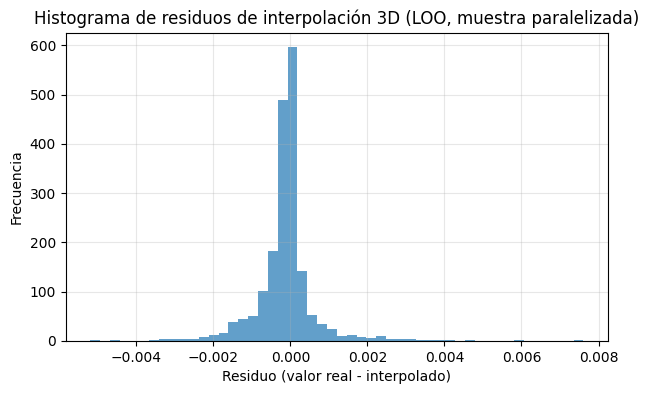

In [ ]:
from joblib import Parallel, delayed
import numpy as np
from scipy.interpolate import griddata

# Parameters
n_sample = 2000  # Number of points to randomly sample
n_jobs = -1      # Use all available cores

# Random selection of points
rng = np.random.default_rng(42)
N = points_3d.shape[0]
idx_sample = rng.choice(N, size=n_sample, replace=False)
points_sample = points_3d[idx_sample]
values_sample = values_3d[idx_sample]

# Function for Leave-One-Out on a point
def loo_error(i):
    mask = np.arange(n_sample) != i
    train_points = points_sample[mask]
    train_values = values_sample[mask]
    test_point = points_sample[i].reshape(1, -1)
    test_value = values_sample[i]
    interp_val = griddata(train_points, train_values, test_point, method='linear')
    if np.isnan(interp_val):
        return None
    error = test_value - interp_val[0]
    rel_error = np.abs(error) / np.abs(test_value) if test_value != 0 else np.nan
    return error, rel_error, test_value, interp_val[0]

results = Parallel(n_jobs=n_jobs, verbose=10)(delayed(loo_error)(i) for i in range(n_sample))

results = [r for r in results if r is not None]
errors_3d, rel_errors_3d, true_vals_3d, pred_vals_3d = map(np.array, zip(*results))

mae_3d = np.mean(np.abs(errors_3d))
mse_3d = np.mean(errors_3d**2)
rmse_3d = np.sqrt(mse_3d)
mean_rel_error_3d = np.nanmean(rel_errors_3d)

print(f"MAE (3D, sample): {mae_3d:.3e}")
print(f"MSE (3D, sample): {mse_3d:.3e}")
print(f"RMSE (3D, sample): {rmse_3d:.3e}")
print(f"Mean relative error (3D, sample): {mean_rel_error_3d:.3%}")

plt.figure(figsize=(7,4))
plt.hist(errors_3d, bins=50, alpha=0.7)
plt.xlabel('Residual (real value - interpolated)')
plt.ylabel('Frequency')
plt.title('Histogram of 3D interpolation residuals (LOO, parallelized sample)')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from joblib import Parallel, delayed
import numpy as np
from scipy.interpolate import griddata

N = points_3d.shape[0]
n_jobs = -1  

def loo_error_full(i):
    mask = np.arange(N) != i
    train_points = points_3d[mask]
    train_values = values_3d[mask]
    test_point = points_3d[i].reshape(1, -1)
    test_value = values_3d[i]
    interp_val = griddata(train_points, train_values, test_point, method='linear')
    if np.isnan(interp_val):
        return None
    error = test_value - interp_val[0]
    rel_error = np.abs(error) / np.abs(test_value) if test_value != 0 else np.nan
    return error, rel_error, test_value, interp_val[0]

results_full = Parallel(n_jobs=n_jobs, verbose=10)(delayed(loo_error_full)(i) for i in range(N))

results_full = [r for r in results_full if r is not None]
errors_3d_full, rel_errors_3d_full, true_vals_3d_full, pred_vals_3d_full = map(np.array, zip(*results_full))

mae_3d_full = np.mean(np.abs(errors_3d_full))
mse_3d_full = np.mean(errors_3d_full**2)
rmse_3d_full = np.sqrt(mse_3d_full)
mean_rel_error_3d_full = np.nanmean(rel_errors_3d_full)

print(f"MAE (3D, all points): {mae_3d_full:.3e}")
print(f"MSE (3D, all points): {mse_3d_full:.3e}")
print(f"RMSE (3D, all points): {rmse_3d_full:.3e}")
print(f"Mean relative error (3D, all points): {mean_rel_error_3d_full:.3%}")

plt.figure(figsize=(7,4))
plt.hist(errors_3d_full, bins=50, alpha=0.7)
plt.xlabel('Residual (real value - interpolated)')
plt.ylabel('Frequency')
plt.title('Histogram of 3D interpolation residuals (LOO, all points)')
plt.grid(alpha=0.3)
plt.show()